# Fitting linear regression models with `statsmodels`

It's time to start building linear regression models so that we can **describe** the relationship between input and output variables as well as **predict** output values for input values we haven't seen. 

We'll use the `statsmodels` package to train (fit) the models. Specifically, we'll use the "formula" interface (API, or application programming interface) of `statsmodels`.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

Pretend you're an employee of a food truck company that is looking to expand locations. You have data on profits and the population of cities with existing franchises to use to aid in the decision of which city to open a new franchise. Here we'll load that data (which is from Andrew Ng's Machine Learning course).

In [2]:
profits = pd.read_csv('https://raw.githubusercontent.com/girishkuniyal/Predict-Profit-for-food-truck/refs/heads/master/ex1data1.txt',
                    header=None,
                    names=['population', 'profit'])
profits.info()
profits.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   population  97 non-null     float64
 1   profit      97 non-null     float64
dtypes: float64(2)
memory usage: 1.6 KB


,population,profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


Let's quickly visualize this data as a scatterplot.

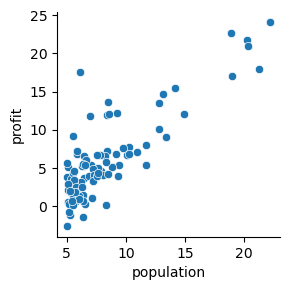

In [3]:
sns.relplot(data=profits, x='population', y='profit', height=3)
plt.show()

# Fit linear regression model
The function for fitting linear regression models in `statsmodels` with the formula interface is `smf.ols()`. It takes two important arguments:
1. A formula describing the model
2. A training dataset

The formula is a string that concisely represents the model we'd like (inspired by the R programming language). Assuming an output variable of `y` and one input variable `x` (column names in a dataset), here's the format of the formula:

`'y ~ x'`

This represents a linear regression model with the mathematical formula:

$$ \hat y = \beta_0 + \beta_1 x $$

Note that there's no need to specify the intercept, $\beta_0$, in the formula for statsmodels. It's assumed.

After initializing the `smf.ols` function, you can call `.fit()` to train the model, or "fit" the model's parameters, on the dataset. Let's try it out with our food truck dataset!

In [4]:
model = smf.ols(formula = 'profit ~ population', data = profits).fit()

In [5]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 profit   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     223.8
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.02e-26
Time:                        10:43:06   Log-Likelihood:                -243.95
No. Observations:                  97   AIC:                             491.9
Df Residuals:                      95   BIC:                             497.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.8958      0.719     -5.415      0.000      -5.324      -2.467
population     1.1930      0.080     14.961      0.000       1.035       1.351
==============================================================================
Omnibus:                       39.986   Durbin-Watson:                   0.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              108.142
Skew:                           1.455   Prob(JB):                     3.29e-24
Kurtosis:                       7.276   Cond. No.                         21.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
model.params

Intercept    -3.895781
population    1.193034
dtype: float64